# **Project: Multi-Scale Feature Engineering for Crop Detection**

**Course:** CSCE 5222 Feature Engineering

### **1. Introduction and Problem Statement**

Hyperspectral classification often struggles with fine-grained differentiation, such as distinguishing between **Corn-notill** and **Corn-mintill**, or distinguishing between varying vegetation states like **Senescence (Hay)** vs. **Vigor (Grass)**.

**The Objective:**
To move beyond standard spectral-only classification by building a **Multi-Scale Spectral-Spatial Feature Engineering Pipeline**.

**The Strategy:**
We approach the problem as a **fine-grained crop status and land cover characterization** task. By fusing spectral data with spatial texture and biological indices, we aim to extract robust proxies that allow us to:

1.  **Differentiate Physiological States:** Distinguishing between photosynthetically active vegetation (Grass) and senesced/dry vegetation (Hay).
2.  **Characterize Field Conditions:** Distinguishing between No-till (High Residue/Moisture) and Min-till (Exposed Soil) environments.

**Methodology:**
Our pipeline stacks **Raw Spectral Bands** with engineered features including:

*   **Biological Indices:** NDVI, NDWI, NDTI, EVI.
*   **Texture Analysis:** Gabor Filters & Local Binary Patterns (LBP).
*   **Spatial Context:** Morphological Profiles (MPs) & Local Variance.
*   **Unsupervised Grouping:** K-Means Clustering.

In [1]:
# ==========================================
# SECTION 1: SETUP & CONFIGURATION
# ==========================================

import numpy as np
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Imports
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

# Image Processing Imports (Texture & Morphology)
from skimage.filters import gabor_kernel
from scipy import ndimage as ndi
from scipy.ndimage import uniform_filter
from skimage.feature import local_binary_pattern
from skimage.morphology import opening, closing, disk

# Visualization Styling
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")

# --- FILE PATHS ---
DATA_PATH = 'Indian_pines.mat'
GT_PATH = 'Indian_pines_gt.mat'

# --- BAND SELECTION ---
# Removing Water Absorption Bands (Noisy/Atmosphere affected data)
# Specific ranges: 104-108, 150-163, 219
BAD_BANDS = list(range(103, 109)) + list(range(149, 164)) + [219]

# --- TARGET CLASS DEFINITION ---
# We filter the dataset to focus on two specific challenges:
# 1. Fine-Grained Classification: Corn & Soybean Tillage (Soil Health)
# 2. Health Dynamics: Grass vs. Hay (Physiological Status)
TARGET_CLASSES = [
    2, 3, 4,       # Corn: Notill, Mintill, General
    10, 11, 12,    # Soybean: Notill, Mintill, Clean
    5, 7, 8        # Vegetation Status: Healthy Grass, Mowed, Dead Hay
]

CLASS_NAMES = {
    2: 'Corn-Notill', 3: 'Corn-Mintill', 4: 'Corn',
    10: 'Soy-Notill', 11: 'Soy-Mintill', 12: 'Soy-Clean',
    5: 'Grass (Healthy)', 7: 'Grass-Mowed (Stress)', 8: 'Hay (Dead)'
}

### 2. Dataset Overview and Preprocessing
**Dataset:** Indian Pines Hyperspectral Dataset (NASA AVIRIS sensor).
*   **Dimensions:** $145 \times 145$ spatial pixels.
*   **Spectral Depth:** 220 bands (0.4–2.5 µm).

**Preprocessing:**
To ensure signal quality, we remove **22 water absorption bands** that contain atmospheric noise. The remaining **198 bands** serve as our baseline "Raw Spectra."

### 2. Dataset Overview and Data Loading
**Dataset:** Indian Pines Hyperspectral Dataset (NASA AVIRIS sensor).

The dataset consists of two files:
1.  **Hyperspectral Image (Indian_pines.mat):**
    *   **Dimensions:**  145 x  145 spatial pixels.
    *   **Spectral Depth:** 220 bands (0.4–2.5 µm) covering the visual and infrared spectrum.
    *   **Preprocessing:** We immediately remove 22 water absorption bands** (bands 104-108, 150-163, 219) that contain atmospheric noise, leaving 198 clean bands.

2.  **Ground Truth Labels (Indian_pines_gt.mat):**
    *   **Dimensions:**  145 x 145 spatial pixels (matching the image).
    *   **Content:** Each pixel is assigned an integer ID (0-16) representing the land cover class.
    *   **Classes:** There are 16 agricultural and geographic classes (e.g., Corn, Soybeans, Woods, Buildings).
    *   **Class 0:** Represents "Background" (unlabeled data) which covers the majority of the image.

Loading Indian Pines Dataset...
Raw Image Shape: (145, 145, 220) (Spatial x Spectral)
Ground Truth Shape: (145, 145) (Spatial Labels)
Cleaned Image Shape: (145, 145, 198) (Water bands removed)


/tmp/ipython-input-547123727.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', 17)


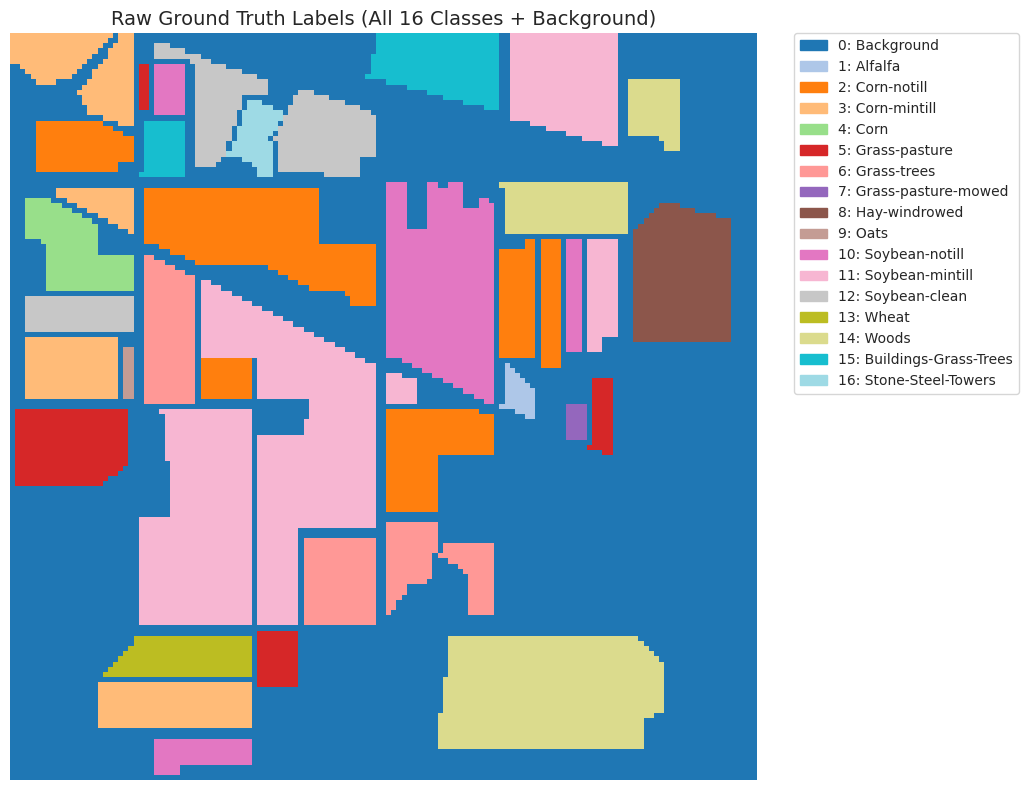

In [2]:
# ==========================================
# SECTION 2: DATA LOADING & RAW INSPECTION
# ==========================================

def load_and_clean_data():
    print("Loading Indian Pines Dataset...")
    try:
        # Load .mat files
        X_raw = scipy.io.loadmat(DATA_PATH)['indian_pines']
        y_raw = scipy.io.loadmat(GT_PATH)['indian_pines_gt']
    except FileNotFoundError:
        print("CRITICAL ERROR: Dataset files not found. Check paths.")
        return None, None

    print(f"Raw Image Shape: {X_raw.shape} (Spatial x Spectral)")
    print(f"Ground Truth Shape: {y_raw.shape} (Spatial Labels)")

    # Remove Water Absorption Bands defined in Setup
    all_bands = np.arange(X_raw.shape[2])
    good_bands = [b for b in all_bands if b not in BAD_BANDS]
    X_clean = X_raw[:, :, good_bands]

    print(f"Cleaned Image Shape: {X_clean.shape} (Water bands removed)")
    return X_clean, y_raw

# Execute Loading
X_img, y_img = load_and_clean_data()

# --- VISUALIZATION: RAW GROUND TRUTH WITH LEGEND ---
# This plot shows EVERY class in the dataset before we filter anything.

# Define the Full Legend for Indian Pines (IDs 0-16)
FULL_CLASSES_LEGEND = {
    0: 'Background',
    1: 'Alfalfa',           2: 'Corn-notill',
    3: 'Corn-mintill',      4: 'Corn',
    5: 'Grass-pasture',     6: 'Grass-trees',
    7: 'Grass-pasture-mowed', 8: 'Hay-windrowed',
    9: 'Oats',              10: 'Soybean-notill',
    11: 'Soybean-mintill',  12: 'Soybean-clean',
    13: 'Wheat',            14: 'Woods',
    15: 'Buildings-Grass-Trees', 16: 'Stone-Steel-Towers'
}

def plot_raw_ground_truth(y):
    plt.figure(figsize=(12, 8))

    # Use a discrete colormap with enough colors for 17 classes
    cmap = plt.cm.get_cmap('tab20', 17)

    # Plot the matrix
    im = plt.imshow(y, cmap=cmap, vmin=0, vmax=16)
    plt.title("Raw Ground Truth Labels (All 16 Classes + Background)", fontsize=14)
    plt.axis('off')

    # Create a custom legend specifically for this plot
    from matplotlib.patches import Patch
    legend_patches = []
    for class_id, class_name in FULL_CLASSES_LEGEND.items():
        # Get the color corresponding to this ID from the colormap
        # We normalize class_id to 0-1 range for the cmap function if needed,
        # but for discrete tab20, we can just index if setup correctly.
        # Here we rely on the imshow mapping.
        color = cmap(class_id)
        legend_patches.append(Patch(color=color, label=f"{class_id}: {class_name}"))

    # Place legend outside the plot
    plt.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    plt.tight_layout()
    plt.show()

# Show the raw map
plot_raw_ground_truth(y_img)

### 3. Exploratory Data Analysis (EDA)
Before engineering features, we visualize the raw spectral data to understand the scene's structure.

**1. False Color Composite (Visualizing the Spectrum):**
Hyperspectral data contains hundreds of bands invisible to the human eye. To visualize this, we map three specific bands to the Red-Green-Blue (RGB) channels of the monitor:
*   **Red Channel:** Band 40 (Near-Infrared / NIR).
*   **Green Channel:** Band 25 (Red light).
*   **Blue Channel:** Band 10 (Green light).

**Interpretation:**
*   **Bright Red/Pink Areas:** Indicate pixels with high NIR reflectance. In agricultural scenes, this typically corresponds to dense vegetation (crops/forests).
*   **Cyan/Grey Areas:** Indicate pixels with low NIR reflectance, typically corresponding to bare soil, roads, or man-made structures.
*   *Note: We apply Robust Scaling (2%-98% percentile) to ignore extreme outliers and improve image contrast.*



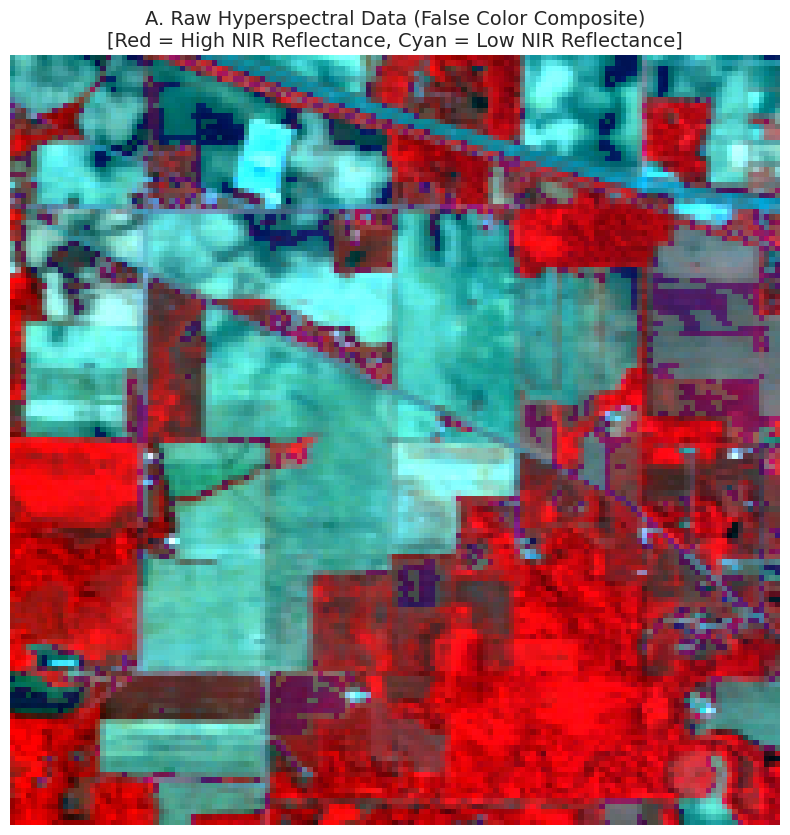

In [3]:
# ==========================================
# SECTION 3: DATASET VISUALIZATIONS
# ==========================================

# --- 1. RAW HYPERSPECTRAL DATA (Robust False Color) ---
plt.figure(figsize=(10, 10))

# Select bands for NIR-Red-Green (Standard False Color)
rgb_indices = [40, 25, 10]
rgb_indices = [b if b < X_img.shape[2] else 0 for b in rgb_indices] # Safety check
img_rgb = X_img[:, :, rgb_indices].astype(float)

# Robust Scaling (2% - 98% percentile)
# This ignores extreme outliers to make the vegetation clearly visible
p2, p98 = np.percentile(img_rgb, (2, 98), axis=(0, 1))
img_rescaled = (img_rgb - p2) / (p98 - p2)
img_rescaled = np.clip(img_rescaled, 0, 1)

plt.imshow(img_rescaled)
plt.title("A. Raw Hyperspectral Data (False Color Composite)\n[Red = High NIR Reflectance, Cyan = Low NIR Reflectance]", fontsize=14)
plt.axis('off')
plt.show()

2.  **Ground Truth Maps:** Compare the Full dataset context vs. our specific **Target Scope**.

/tmp/ipython-input-1233097063.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_full = plt.cm.get_cmap('tab20', 17)


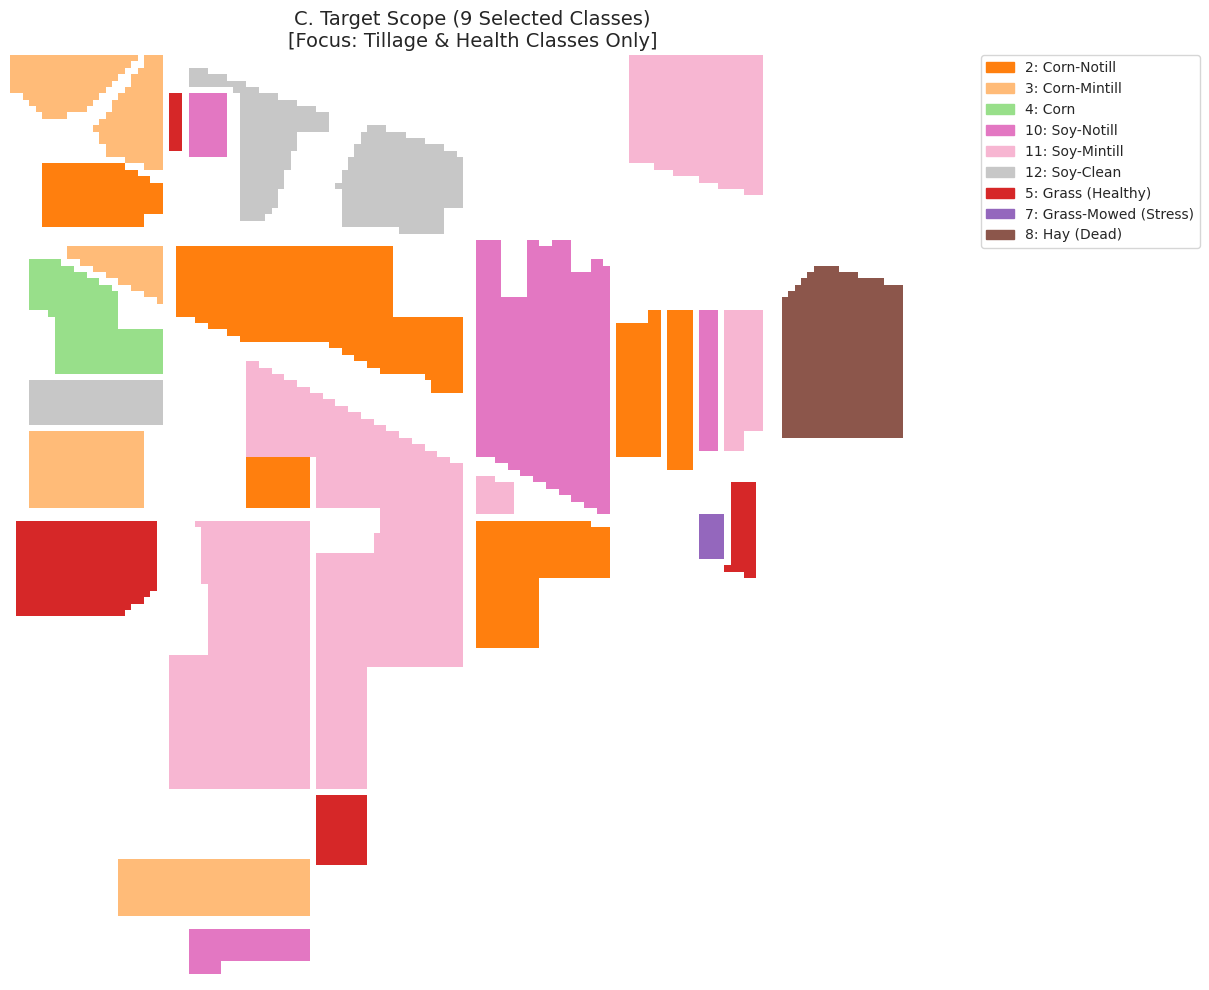

In [4]:
# --- 2. TARGET CLASS MAP ---
plt.figure(figsize=(12, 10)) # Slightly wider for legend

# Create a map showing ONLY our target classes
y_target_only = np.zeros_like(y_img)
for r in range(y_img.shape[0]):
    for c in range(y_img.shape[1]):
        if y_img[r, c] in TARGET_CLASSES:
            y_target_only[r, c] = y_img[r, c]

# Mask everything else
y_target_masked = np.ma.masked_where(y_target_only == 0, y_target_only)
cmap_full = plt.cm.get_cmap('tab20', 17)

# Use the colormap
plt.imshow(y_target_masked, cmap='tab20', vmin=0, vmax=16)
plt.title(f"C. Target Scope ({len(TARGET_CLASSES)} Selected Classes)\n[Focus: Tillage & Health Classes Only]", fontsize=14)
plt.axis('off')

# --- ADD LEGEND ---
from matplotlib.patches import Patch
legend_patches = []
# Loop through our specific target classes to build the legend
for class_id in TARGET_CLASSES:
    class_name = CLASS_NAMES[class_id]
    color = cmap_full(class_id) # Get the exact color from the colormap
    legend_patches.append(Patch(color=color, label=f"{class_id}: {class_name}"))

plt.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

3.  **Class Distribution:** Highlights the severe class imbalance (e.g., thousands of Corn samples vs. very few Grass-Mowed samples), necessitating stratified sampling later.

/tmp/ipython-input-2200344385.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette='viridis')


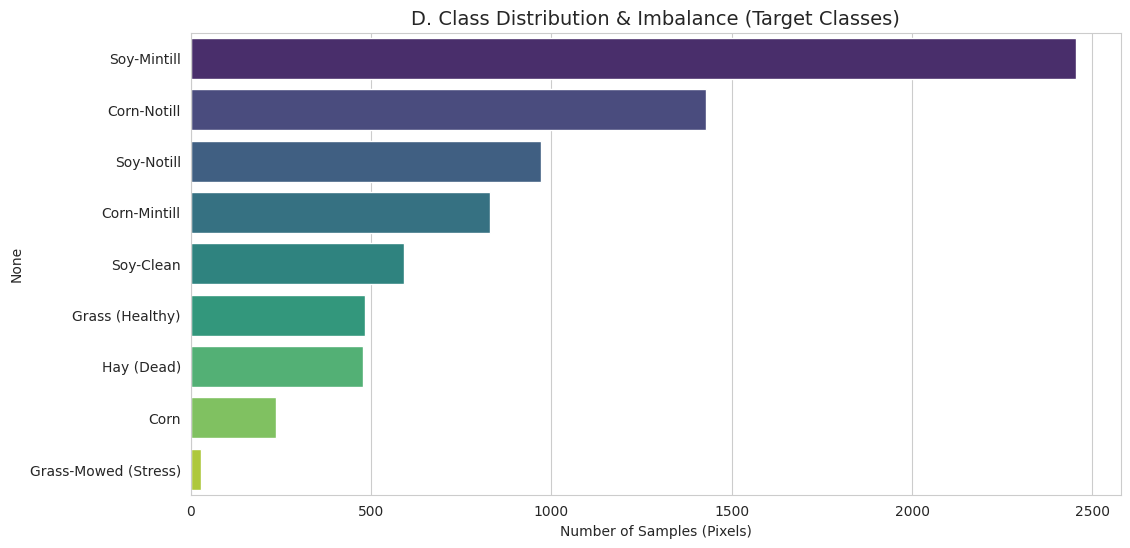

In [5]:
# --- 3. CLASS DISTRIBUTION ---
plt.figure(figsize=(12, 6))

labels_flat = y_img.flatten()
mask = np.isin(labels_flat, TARGET_CLASSES)
filtered_labels = labels_flat[mask]
counts = pd.Series(filtered_labels).map(CLASS_NAMES).value_counts()

sns.barplot(x=counts.values, y=counts.index, palette='viridis')
plt.title("D. Class Distribution & Imbalance (Target Classes)", fontsize=14)
plt.xlabel("Number of Samples (Pixels)")
plt.show()

### 4. Feature Engineering
This section implements the core logic of the proposal. We construct a **Multi-Scale Feature Vector** by extracting and stacking four types of information:

1.  **Biochemical (Indices):**
    *   **NDVI & EVI:** Quantify photosynthetic vigor and biomass (correcting for soil/atmosphere).
    *   **NDWI:** Quantifies canopy water content (Health indicator).
    *   **NDTI:** Quantifies crop residue (Tillage indicator).
2.  **Structural (PCA):**
    *   **Global PCA:** Captures the primary material variance of the scene.
    *   **Local Variance:** Captures surface roughness (5x5 window).
3.  **Textural (Spatial):**
    *   **Gabor Filters:** Detect row alignment and frequency (crucial for Tillage).
    *   **LBP:** Detects micro-texture patterns.
    *   **Morphological Profiles (MPs):** Captures the size and shape of objects (Opening/Closing).
4.  **Unsupervised (Clustering):**
    *   **K-Means:** Provides a "Spectral Hint" by pre-grouping similar pixels.

**Fusion Strategy:** We use **Feature Stacking**. The engineered features are concatenated with the raw spectral bands, ensuring the model has access to both the original data and the enhanced insights.

In [6]:
# ==========================================
# SECTION 4: FEATURE ENGINEERING (COMPLETE)
# Includes: NDVI, NDWI, NDTI, EVI, PCA, Variance, Gabor, MPs, LBP, Clusters
# ==========================================

class FeatureEngineer:
    def __init__(self, X_cube):
        self.H, self.W, self.D = X_cube.shape
        self.X_cube = X_cube

    def get_spectral_indices(self):
        """
        Calculates Biological Indices to proxy Health and Soil Status.
        Includes clipping for EVI to prevent mathematical instability.
        """
        print("   > Engineering Indices (NDVI, NDWI, NDTI, EVI)...")
        # Define Band Indices (Approximate for AVIRIS)
        idx_blue, idx_green, idx_red, idx_nir = 9, 15, 27, 42
        idx_swir1, idx_swir2 = min(140, self.D-1), min(190, self.D-1)

        # Extract bands
        blue = self.X_cube[:, :, idx_blue].astype(float)
        green = self.X_cube[:, :, idx_green].astype(float)
        red = self.X_cube[:, :, idx_red].astype(float)
        nir = self.X_cube[:, :, idx_nir].astype(float)
        swir1 = self.X_cube[:, :, idx_swir1].astype(float)
        swir2 = self.X_cube[:, :, idx_swir2].astype(float)
        epsilon = 1e-6

        # 1. NDVI (Vigor)
        ndvi = (nir - red) / (nir + red + epsilon)
        # 2. NDWI (Moisture)
        ndwi = (green - nir) / (green + nir + epsilon)
        # 3. NDTI (Tillage/Residue)
        ndti = (swir1 - swir2) / (swir1 + swir2 + epsilon)

        # 4. EVI (Enhanced Vigor - Atmosphere/Soil Corrected)
        G, C1, C2, L = 2.5, 6.0, 7.5, 1.0
        denominator = (nir + C1 * red - C2 * blue + L)
        denominator[denominator == 0] = epsilon # Avoid div by zero
        evi = G * ((nir - red) / denominator)

        # Critical Fix: Clamp EVI to valid range [-1, 1] to remove outliers
        evi = np.clip(evi, -1.0, 1.0)

        return np.stack([ndvi, ndwi, ndti, evi], axis=2)

    def get_multiscale_pca(self):
        """
        Extracts Structure (Global PCA) and Roughness (Local Variance).
        """
        print("   > Engineering Multi-Scale PCA...")
        flat_X = self.X_cube.reshape(-1, self.D)

        # Global Structure
        pca = PCA(n_components=3)
        X_pca = pca.fit_transform(flat_X).reshape(self.H, self.W, 3)

        # Local Roughness (Variance on PC1)
        pc1 = X_pca[:, :, 0]
        mean_sq = uniform_filter(pc1**2, size=5)
        sq_mean = uniform_filter(pc1, size=5)**2
        local_std = np.sqrt(np.maximum(mean_sq - sq_mean, 0)).reshape(self.H, self.W, 1)

        return X_pca, local_std

    def get_gabor_texture(self):
        """
        Extracts Orientation-Specific Texture (Gabor Filters).
        """
        print("   > Engineering Gabor Texture...")
        flat_X = self.X_cube.reshape(-1, self.D)
        pc1 = PCA(n_components=1).fit_transform(flat_X).reshape(self.H, self.W)

        gabor_feats = []
        # 4 Orientations (0, 45, 90, 135)
        for theta in range(4):
            theta = theta / 4. * np.pi
            for sigma in (1, 3):
                for frequency in (0.05, 0.25):
                    kernel = np.real(gabor_kernel(frequency, theta=theta, sigma_x=sigma, sigma_y=sigma))
                    filtered = ndi.convolve(pc1, kernel, mode='wrap')
                    gabor_feats.append(filtered)
        return np.stack(gabor_feats, axis=2)

    def get_morphological_profiles(self):
        """
        Extracts Object Size/Shape (Morphological Profiles).
        """
        print("   > Engineering Morphological Profiles...")
        flat_X = self.X_cube.reshape(-1, self.D)
        pc1 = PCA(n_components=1).fit_transform(flat_X).reshape(self.H, self.W)
        # Normalize 0-1 for morphology
        pc1 = (pc1 - pc1.min()) / (pc1.max() - pc1.min())

        mp_feats = []
        # Opening (Remove bright spots) / Closing (Remove dark spots)
        for radius in [3, 5, 7]:
            selem = disk(radius)
            mp_feats.append(opening(pc1, selem))
            mp_feats.append(closing(pc1, selem))
        return np.stack(mp_feats, axis=2)

    def get_lbp_texture(self):
        """
        Extracts Micro-Texture (Local Binary Patterns).
        """
        print("   > Engineering LBP Texture...")
        flat_X = self.X_cube.reshape(-1, self.D)
        pc1 = PCA(n_components=1).fit_transform(flat_X).reshape(self.H, self.W)
        # Normalize to integer 0-255
        pc1_norm = ((pc1 - pc1.min()) / (pc1.max() - pc1.min()) * 255).astype(int)
        lbp = local_binary_pattern(pc1_norm, P=24, R=3, method='uniform')
        return lbp.reshape(self.H, self.W, 1)

    def get_unsupervised_clusters(self):
        """
        Extracts Spectral Groupings (K-Means).
        """
        print("   > Engineering Unsupervised Clusters...")
        flat_X = self.X_cube.reshape(-1, self.D)
        # K=16 matches the total number of ground truth classes
        kmeans = KMeans(n_clusters=16, random_state=42, n_init=10)
        clusters = kmeans.fit_predict(flat_X)
        return clusters.reshape(self.H, self.W, 1)

    def build_dataset(self):
        print("Starting Feature Engineering Pipeline...")
        # Generate Features
        f_idx = self.get_spectral_indices()       # 4 Feats
        f_pca, f_var = self.get_multiscale_pca()  # 4 Feats
        f_gabor = self.get_gabor_texture()        # 16 Feats
        f_mp = self.get_morphological_profiles()  # 6 Feats
        f_lbp = self.get_lbp_texture()            # 1 Feat
        f_clus = self.get_unsupervised_clusters() # 1 Feat

        print("   > Fusing Data (Stacking Strategy)...")
        # FUSION: Raw Bands + All Engineered Features
        X_fused = np.concatenate([
            self.X_cube, f_idx, f_pca, f_var, f_gabor, f_mp, f_lbp, f_clus
        ], axis=2)

        return X_fused, f_idx, f_pca, f_var, f_gabor, f_mp, f_lbp, f_clus

# Execute Pipeline
engineer = FeatureEngineer(X_img)
# Unpack variables for Section 5 visualization
X_fused, d_idx, d_pca, d_var, d_gabor, d_mp, d_lbp, d_clus = engineer.build_dataset()

print("\n--- FEATURE ENGINEERING COMPLETE ---")
print(f"Baseline Data Shape: {X_img.shape} (Raw Bands)")
print(f"Proposed Data Shape: {X_fused.shape} (Raw + Engineered)")

Starting Feature Engineering Pipeline...
   > Engineering Indices (NDVI, NDWI, NDTI, EVI)...
   > Engineering Multi-Scale PCA...
   > Engineering Gabor Texture...
   > Engineering Morphological Profiles...
   > Engineering LBP Texture...
   > Engineering Unsupervised Clusters...
   > Fusing Data (Stacking Strategy)...

--- FEATURE ENGINEERING COMPLETE ---
Baseline Data Shape: (145, 145, 198) (Raw Bands)
Proposed Data Shape: (145, 145, 230) (Raw + Engineered)


### 5. Feature Visualization Gallery
To validate our feature engineering process, we visualize the generated feature maps. These plots serve as "Explainable AI" artifacts, allowing us to interpret what the model "sees" before training.

**Key Interpretations:**

1.  **Biological Indices:**
    *   **NDVI & EVI (Health):** Green areas indicate healthy, dense vegetation (high biomass). Red/Yellow areas indicate exposed soil or senesced (dead) vegetation.
    *   **NDWI (Moisture):** Darker blue indicates higher canopy water content (crucial for distinguishing living Grass from dry Hay).
    *   **NDTI (Tillage):** Brown highlights exposed soil (Clean/Min-till), while Teal/Green highlights crop residue (No-till).







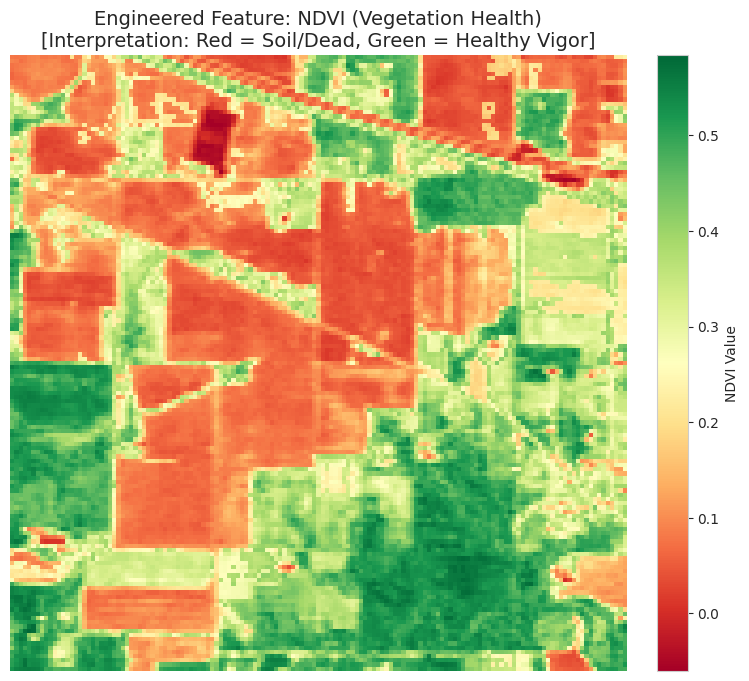

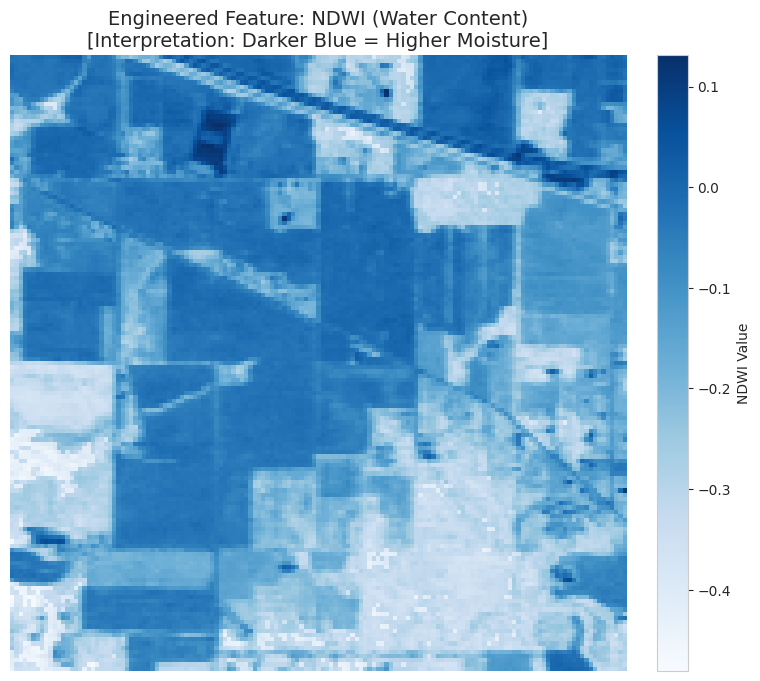

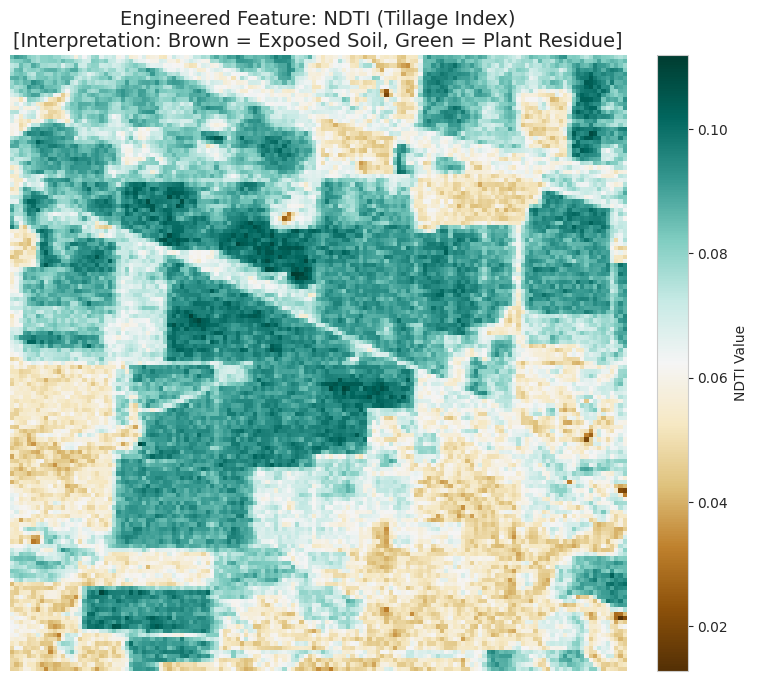

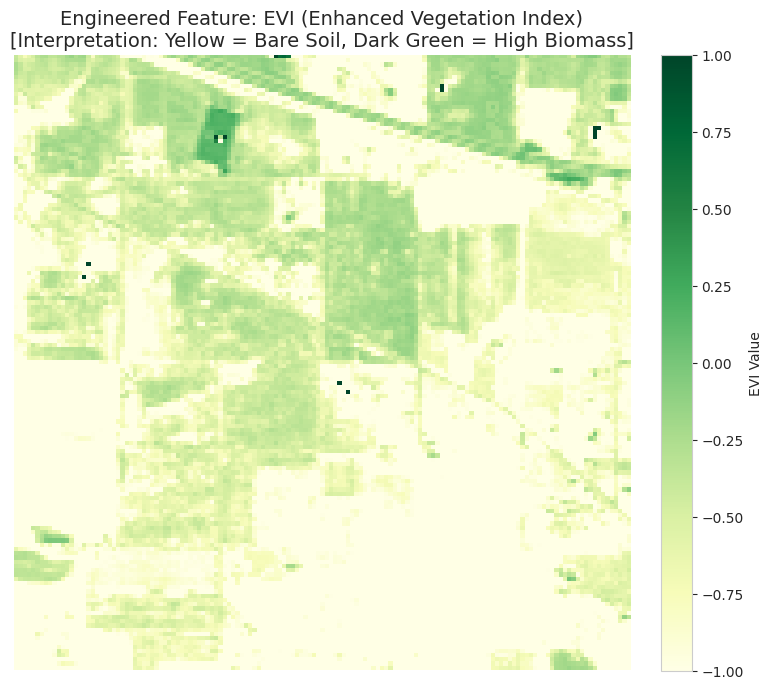

In [7]:
# ==========================================
# SECTION 5: INDIVIDUAL FEATURE VISUALIZATION
# ==========================================

# --- 1. NDVI (Vegetation Health) ---
plt.figure(figsize=(10, 8))
plt.imshow(d_idx[:, :, 0], cmap='RdYlGn')
plt.title("Engineered Feature: NDVI (Vegetation Health)\n[Interpretation: Red = Soil/Dead, Green = Healthy Vigor]", fontsize=14)
plt.colorbar(label='NDVI Value', fraction=0.046, pad=0.04)
plt.axis('off')
plt.show()

# --- 2. NDWI (Water Content) ---
plt.figure(figsize=(10, 8))
plt.imshow(d_idx[:, :, 1], cmap='Blues')
plt.title("Engineered Feature: NDWI (Water Content)\n[Interpretation: Darker Blue = Higher Moisture]", fontsize=14)
plt.colorbar(label='NDWI Value', fraction=0.046, pad=0.04)
plt.axis('off')
plt.show()

# --- 3. NDTI (Tillage Index) ---
plt.figure(figsize=(10, 8))
plt.imshow(d_idx[:, :, 2], cmap='BrBG')
plt.title("Engineered Feature: NDTI (Tillage Index)\n[Interpretation: Brown = Exposed Soil, Green = Plant Residue]", fontsize=14)
plt.colorbar(label='NDTI Value', fraction=0.046, pad=0.04)
plt.axis('off')
plt.show()

# --- 4. EVI (Enhanced Vegetation Index) ---
plt.figure(figsize=(10, 8))
plt.imshow(d_idx[:, :, 3], cmap='YlGn')
plt.title("Engineered Feature: EVI (Enhanced Vegetation Index)\n[Interpretation: Yellow = Bare Soil, Dark Green = High Biomass]", fontsize=14)
plt.colorbar(label='EVI Value', fraction=0.046, pad=0.04)
plt.axis('off')
plt.show()


2.  **Structural Features:**
    *   **Global PCA:** Captures the primary structural layout of the scene, separating major material differences (e.g., Fields vs. Roads).
    *   **Local Variance:** Captures surface roughness. Bright areas indicate high variance (edges, rough canopies); dark areas indicate smooth, uniform fields.

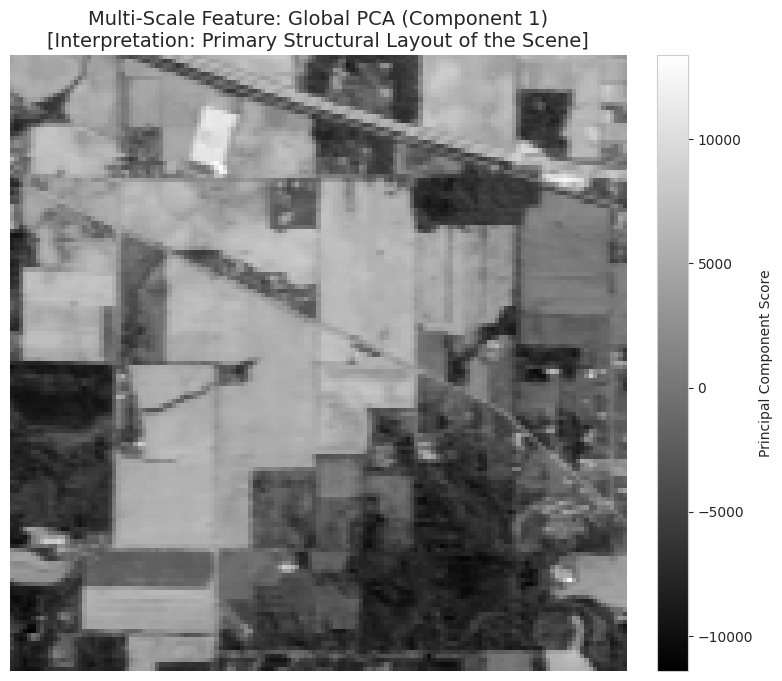

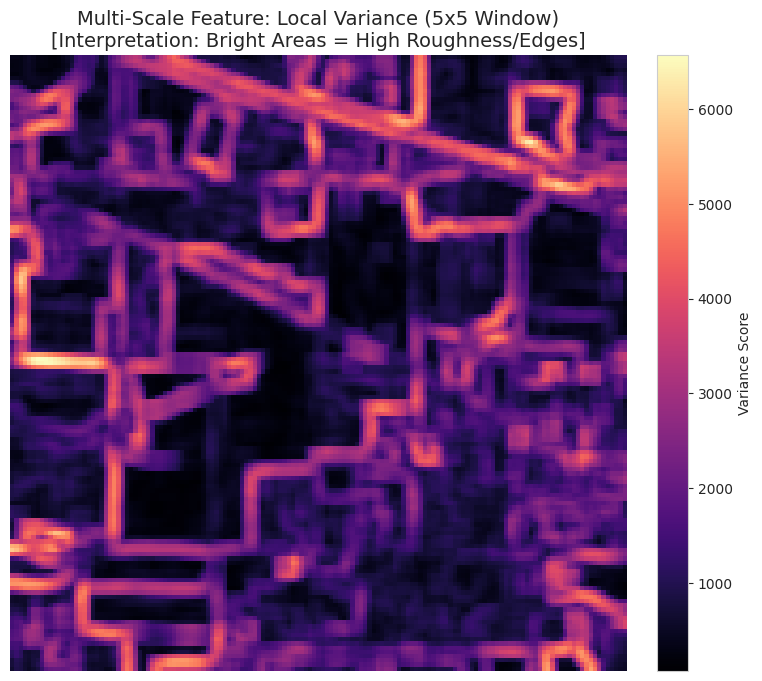

In [8]:
# --- 5. Global PCA (Structure) ---
plt.figure(figsize=(10, 8))
plt.imshow(d_pca[:, :, 0], cmap='gray')
plt.title("Multi-Scale Feature: Global PCA (Component 1)\n[Interpretation: Primary Structural Layout of the Scene]", fontsize=14)
plt.colorbar(label='Principal Component Score', fraction=0.046, pad=0.04)
plt.axis('off')
plt.show()

# --- 6. Local Variance (Roughness) ---
plt.figure(figsize=(10, 8))
plt.imshow(d_var[:, :, 0], cmap='magma')
plt.title("Multi-Scale Feature: Local Variance (5x5 Window)\n[Interpretation: Bright Areas = High Roughness/Edges]", fontsize=14)
plt.colorbar(label='Variance Score', fraction=0.046, pad=0.04)
plt.axis('off')
plt.show()

3.  **Spatial & Textural Features:**
    *   **Gabor Filters:** Direction-sensitive texture. 0° highlights horizontal crop rows; 45° highlights diagonal planting patterns.
    *   **Morphological Profiles (MPs):** "Opening" filters out small bright objects to highlight large field structures. "Closing" fills in small dark gaps. Together, they describe object size and shape.
    *   **Local Binary Patterns (LBP):** Captures micro-texture (smoothness vs. roughness) at the pixel level, helping distinguish canopy density.

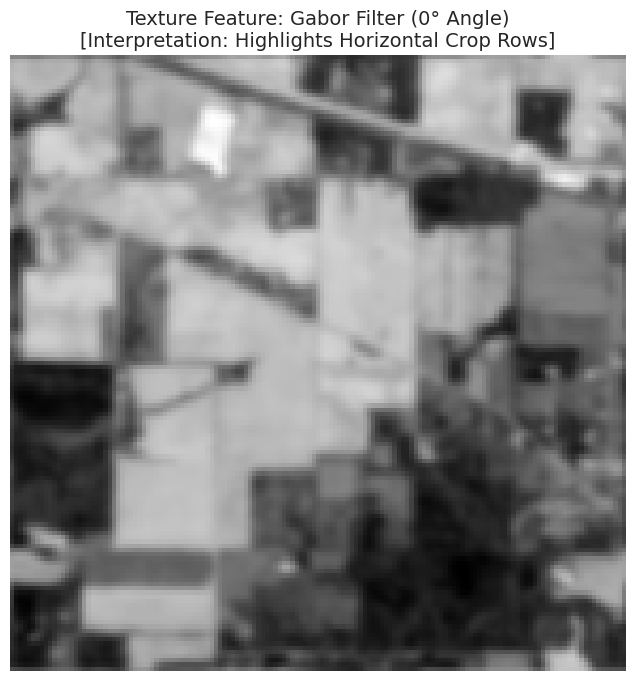

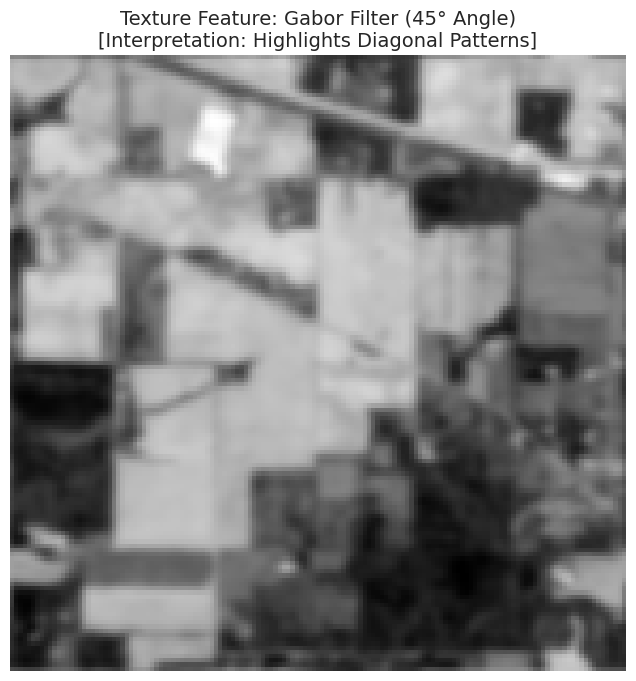

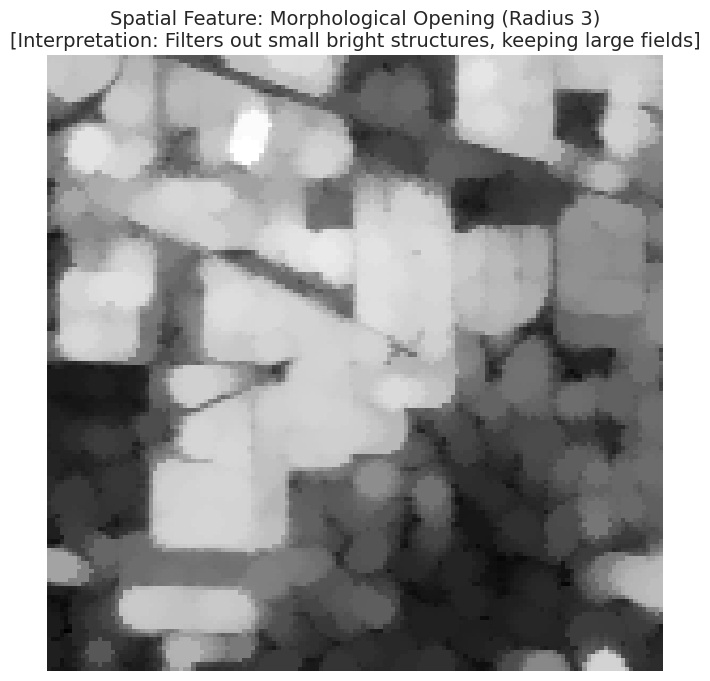

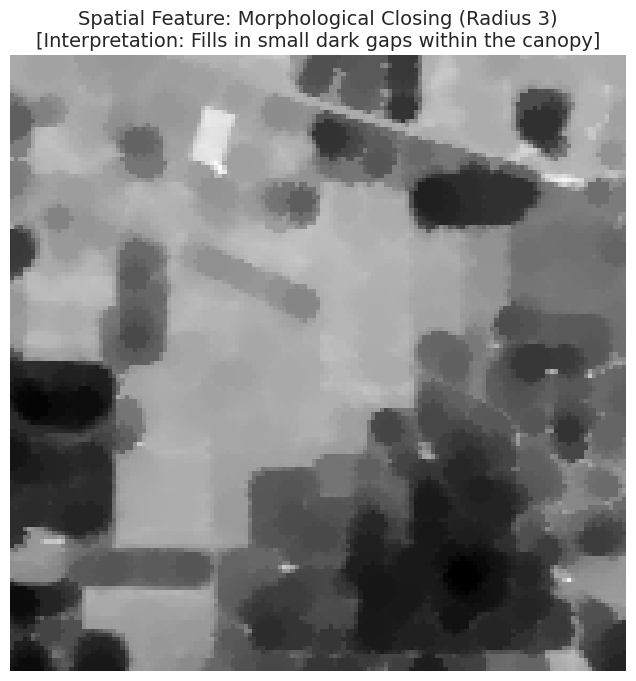

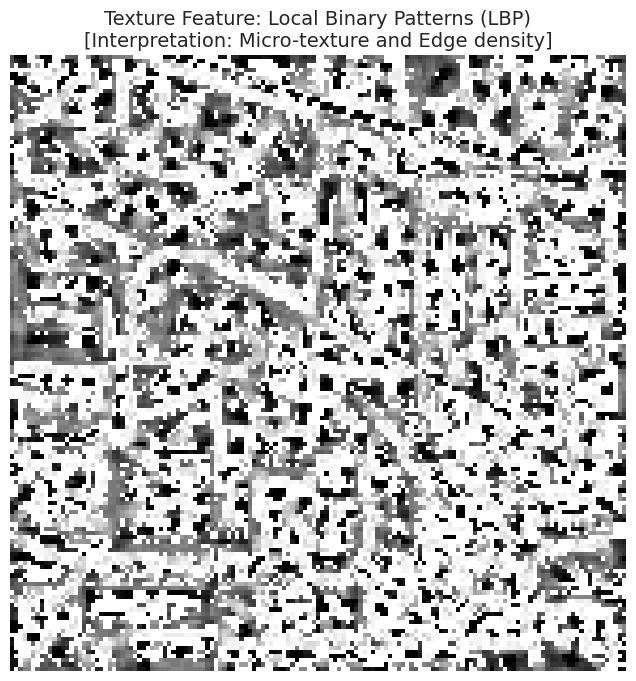

In [9]:
# --- 7. Gabor Filter (Horizontal Texture) ---
plt.figure(figsize=(10, 8))
plt.imshow(d_gabor[:, :, 0], cmap='gray')
plt.title("Texture Feature: Gabor Filter (0° Angle)\n[Interpretation: Highlights Horizontal Crop Rows]", fontsize=14)
plt.axis('off')
plt.show()

# --- 8. Gabor Filter (Diagonal Texture) ---
plt.figure(figsize=(10, 8))
plt.imshow(d_gabor[:, :, 4], cmap='gray')
plt.title("Texture Feature: Gabor Filter (45° Angle)\n[Interpretation: Highlights Diagonal Patterns]", fontsize=14)
plt.axis('off')
plt.show()

# --- 9. Morphological Profile (Opening) ---
plt.figure(figsize=(10, 8))
plt.imshow(d_mp[:, :, 0], cmap='gray')
plt.title("Spatial Feature: Morphological Opening (Radius 3)\n[Interpretation: Filters out small bright structures, keeping large fields]", fontsize=14)
plt.axis('off')
plt.show()

# --- 10. Morphological Profile (Closing) ---
plt.figure(figsize=(10, 8))
plt.imshow(d_mp[:, :, 1], cmap='gray')
plt.title("Spatial Feature: Morphological Closing (Radius 3)\n[Interpretation: Fills in small dark gaps within the canopy]", fontsize=14)
plt.axis('off')
plt.show()

# --- 11. Local Binary Patterns (LBP) ---
plt.figure(figsize=(10, 8))
plt.imshow(d_lbp[:, :, 0], cmap='gray')
plt.title("Texture Feature: Local Binary Patterns (LBP)\n[Interpretation: Micro-texture and Edge density]", fontsize=14)
plt.axis('off')
plt.show()


4.  **Unsupervised Grouping:**
    *   **K-Means Clusters:** The map automatically segments major fields based on spectral similarity alone, providing the model with a high-level "categorical hint."

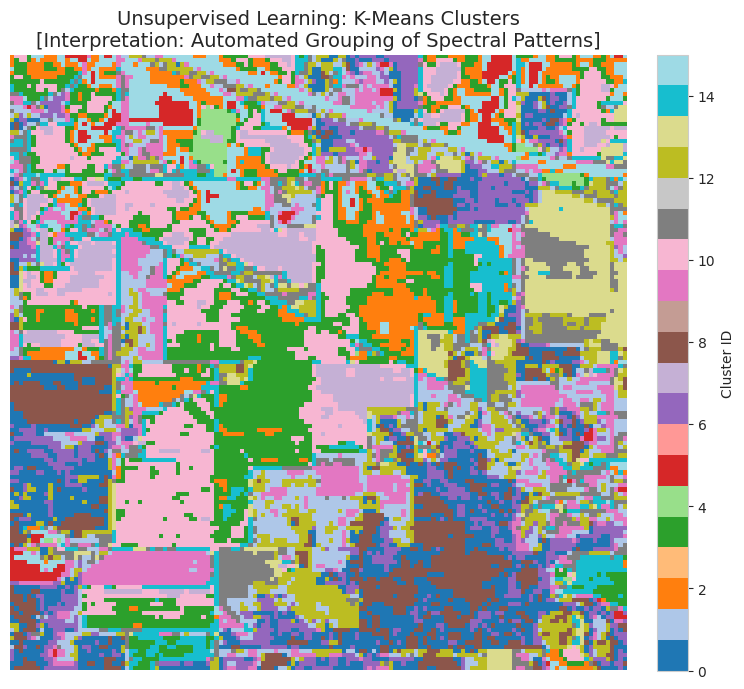

In [10]:
# --- 12. Unsupervised Clusters ---
plt.figure(figsize=(10, 8))
plt.imshow(d_clus[:, :, 0], cmap='tab20')
plt.title("Unsupervised Learning: K-Means Clusters\n[Interpretation: Automated Grouping of Spectral Patterns]", fontsize=14)
plt.colorbar(label='Cluster ID', fraction=0.046, pad=0.04)
plt.axis('off')
plt.show()

### 6. Data Preparation and Splitting
Here we prepare the data for machine learning.
1.  **Flattening:** Converting the 3D image cube into a 2D matrix (Samples x Features).
2.  **Filtering:** Removing "Background" and irrelevant classes (e.g., Woods, Buildings) to focus on our agricultural target classes.
3.  **Splitting:** We use a **Stratified 70/30 Train/Test Split**. Stratification is crucial due to the severe class imbalance shown in the EDA section.
4.  **Scaling:** We apply **StandardScaler** to normalize the features (essential for SVM and KNN performance).

In [11]:
# ==========================================
# SECTION 6: DATA PREPARATION
# ==========================================

def prepare_data(X_cube, y_map):
    print("   > Flattening and Filtering Data...")
    pixels = X_cube.reshape(-1, X_cube.shape[2])
    labels = y_map.reshape(-1)

    # Filter Target Classes
    mask = np.isin(labels, TARGET_CLASSES)
    X = pixels[mask]
    y = labels[mask]

    print(f"   > Samples after filtering: {X.shape[0]}")

    # Stratified Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )

    # Scaling (Crucial: Fit on Train, Transform Test)
    # We return the scaler so we can use it later for visualization
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test, scaler

print("--- PREPARING BASELINE DATA (Raw Bands) ---")
X_b_train, X_b_test, y_train, y_test, _ = prepare_data(X_img, y_img)

print("\n--- PREPARING PROPOSED DATA (Fused Features) ---")
X_p_train, X_p_test, _, _, scaler_model = prepare_data(X_fused, y_img)

--- PREPARING BASELINE DATA (Raw Bands) ---
   > Flattening and Filtering Data...
   > Samples after filtering: 7504

--- PREPARING PROPOSED DATA (Fused Features) ---
   > Flattening and Filtering Data...
   > Samples after filtering: 7504


### 7. Model Training and Evaluation
We perform a rigorous comparative analysis between two scenarios:
1.  **Baseline:** Models trained on Raw Spectral Data only.
2.  **Proposed:** Models trained on the Fused Feature Vector (Spectral + Indices + Texture + Clusters).

**Algorithms:**
*   **KNN (K-Nearest Neighbors):** A simple distance-based baseline.
*   **SVM (Support Vector Machine):** Robust for high-dimensional data.
*   **Random Forest (RF):** An ensemble method that handles complex interactions and provides feature importance.

In [12]:
# ==========================================
# SECTION 7: MODEL TRAINING & EVALUATION
# ==========================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, cohen_kappa_score
from sklearn.metrics import f1_score

# Define Models
models_config = {
    'KNN': KNeighborsClassifier(n_neighbors=5, weights='distance'),
    'SVM': SVC(kernel='rbf', class_weight='balanced', cache_size=1000),
    'RF': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
}

results = {}

print("--- STARTING EXPERIMENT ---")

# 1. Baseline Training
print("\n[1/2] Training Baseline Models (Raw Data)...")
for name, model in models_config.items():
    print(f"   > Training {name}...")
    model.fit(X_b_train, y_train)
    preds = model.predict(X_b_test)

    results[f'Base_{name}'] = {
        'Accuracy': accuracy_score(y_test, preds),
        'Kappa': cohen_kappa_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds, average='weighted'), # Added
        'Preds': preds
    }

# 2. Proposed Training
print("\n[2/2] Training Proposed Models (Engineered Data)...")
for name, model in models_config.items():
    print(f"   > Training {name}...")
    model.fit(X_p_train, y_train)
    preds = model.predict(X_p_test)

    results[f'Prop_{name}'] = {
        'Accuracy': accuracy_score(y_test, preds),
        'Kappa': cohen_kappa_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds, average='weighted'), # Added
        'Preds': preds,
        'Model_Obj': model if name == 'RF' else None
    }

print("\n--- EXPERIMENT COMPLETE ---")

--- STARTING EXPERIMENT ---

[1/2] Training Baseline Models (Raw Data)...
   > Training KNN...
   > Training SVM...
   > Training RF...

[2/2] Training Proposed Models (Engineered Data)...
   > Training KNN...
   > Training SVM...
   > Training RF...

--- EXPERIMENT COMPLETE ---


### 8. Comparative Results Analysis
We analyze the impact of our feature engineering by comparing the **Overall Accuracy** and **Cohen's Kappa** of the Proposed models against the Baseline. A significant increase in accuracy validates the effectiveness of the engineered features.

FINAL RESULTS TABLE (With Weighted F1-Score):
              Type Model  Accuracy  F1-Score     Kappa
Base_KNN  Baseline   KNN  0.773535  0.769747  0.718223
Base_SVM  Baseline   SVM  0.784636   0.78635  0.740987
Base_RF   Baseline    RF  0.851687  0.849774  0.815317
Prop_KNN  Proposed   KNN  0.831705  0.830037  0.790736
Prop_SVM  Proposed   SVM   0.83659  0.839018  0.803288
Prop_RF   Proposed    RF  0.936945  0.936798  0.921866


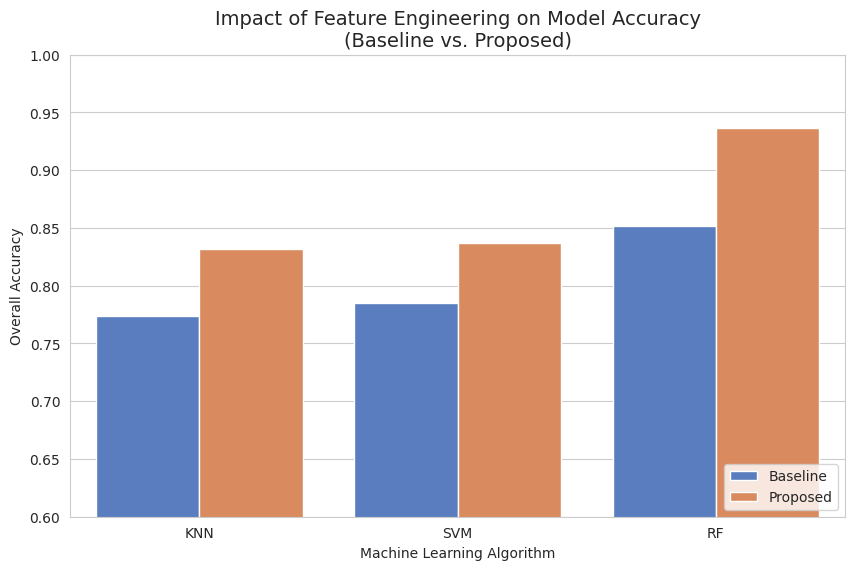

In [13]:
# ==========================================
# SECTION 8: COMPARATIVE RESULTS
# ==========================================

# Convert results to DataFrame
df_res = pd.DataFrame(results).T
df_res['Type'] = df_res.index.map(lambda x: 'Baseline' if 'Base' in x else 'Proposed')
df_res['Model'] = df_res.index.map(lambda x: x.split('_')[1])

# Reorder columns to include F1-Score
df_res = df_res[['Type', 'Model', 'Accuracy', 'F1-Score', 'Kappa']]

print("FINAL RESULTS TABLE (With Weighted F1-Score):")
print(df_res)

# Plot Comparison (Accuracy is usually sufficient for the chart, but the table now holds the detail)
plt.figure(figsize=(10, 6))
sns.barplot(data=df_res, x='Model', y='Accuracy', hue='Type', palette='muted')
plt.ylim(0.6, 1.0)
plt.title("Impact of Feature Engineering on Model Accuracy\n(Baseline vs. Proposed)", fontsize=14)
plt.ylabel("Overall Accuracy")
plt.xlabel("Machine Learning Algorithm")
plt.legend(loc='lower right')
plt.show()

### 9. Deep Dive: Fine-Grained Analysis and Feature Importance
We now dig deeper into the results of our best model (**Proposed Random Forest**) to prove we achieved the specific goals of the proposal.

1.  **Confusion Matrix:** To visualize misclassifications.
2.  **Domain-Specific Metrics:**
    *   **Health Dynamics:** Accuracy in separating Grass vs. Hay.
    *   **Fine-Grained Tillage:** Accuracy in separating Corn-Notill vs. Corn-Mintill.
3.  **Feature Importance:** To scientifically prove that the model relied on our engineered features (Red bars) rather than just the raw data (Blue bars).

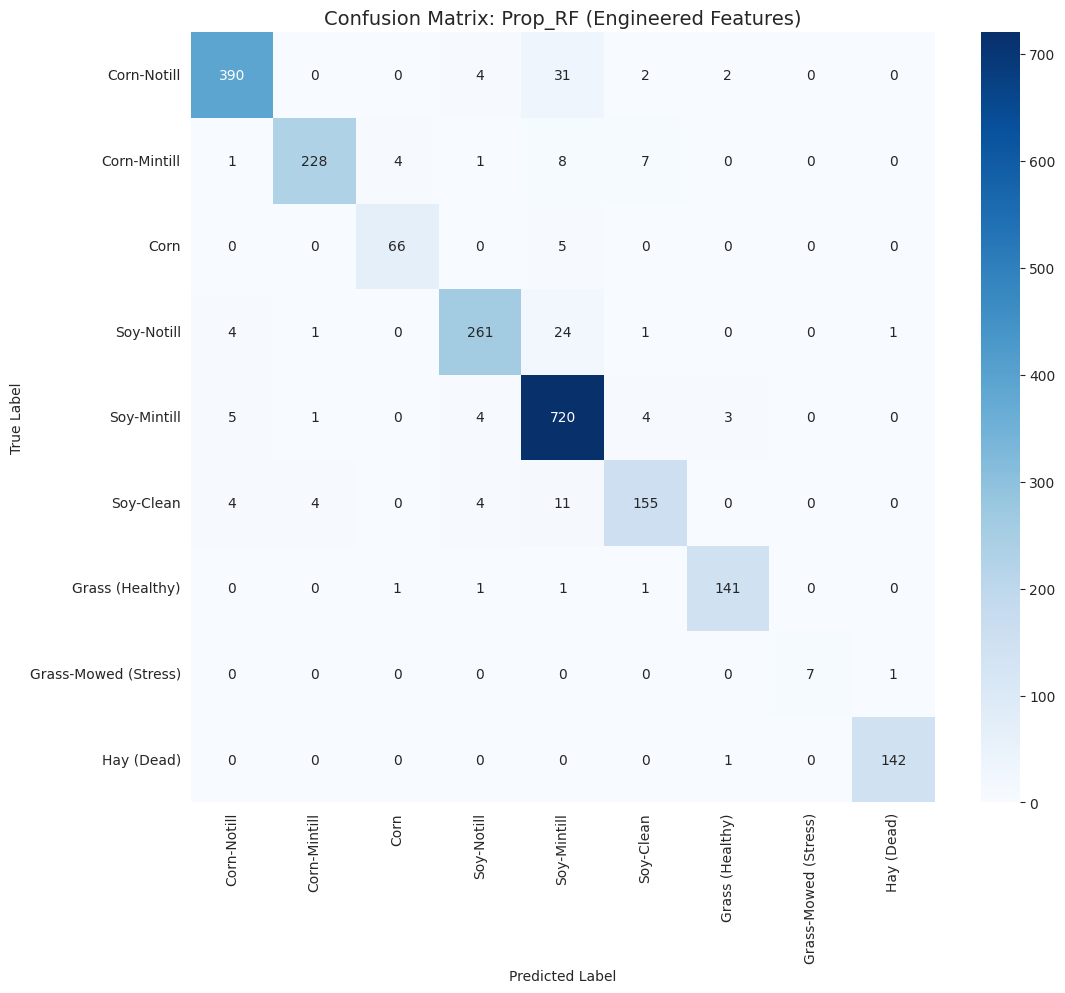

--- DOMAIN-SPECIFIC INSIGHTS ---
1. Health Dynamics Accuracy (Grass vs Hay): 98.26%
2. Fine-Grained Tillage Accuracy (Corn No-Till vs Min-Till): 91.15%


/tmp/ipython-input-3483706108.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_names, palette=colors)


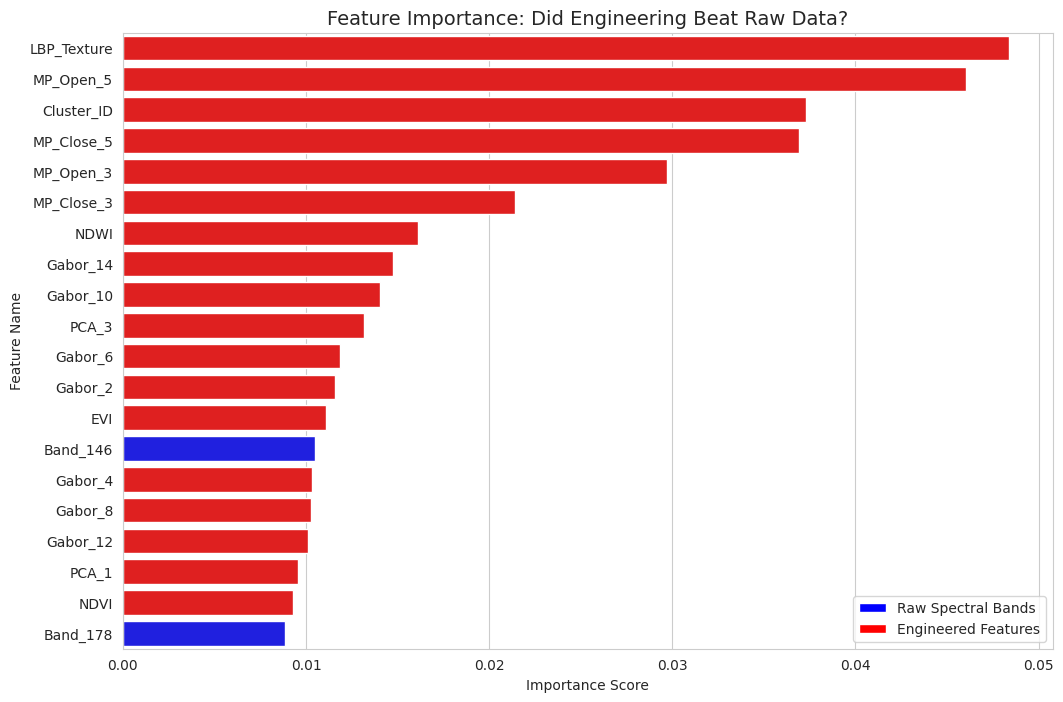

In [14]:
# ==========================================
# SECTION 9: DEEP DIVE & VALIDATION
# ==========================================
from sklearn.metrics import confusion_matrix # Added import for confusion_matrix
from matplotlib.patches import Patch


best_model_name = 'Prop_RF'
y_pred_final = results[best_model_name]['Preds']
rf_model = results[best_model_name]['Model_Obj']

# --- 1. CONFUSION MATRIX ---
cm = confusion_matrix(y_test, y_pred_final, labels=TARGET_CLASSES)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[CLASS_NAMES[i] for i in TARGET_CLASSES],
            yticklabels=[CLASS_NAMES[i] for i in TARGET_CLASSES])
plt.title(f"Confusion Matrix: {best_model_name} (Engineered Features)", fontsize=14)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

# --- 2. DOMAIN-SPECIFIC METRICS ---
print("--- DOMAIN-SPECIFIC INSIGHTS ---")
# Health Dynamics
mask_health = np.isin(y_test, [5, 8])
acc_health = accuracy_score(y_test[mask_health], y_pred_final[mask_health])
print(f"1. Health Dynamics Accuracy (Grass vs Hay): {acc_health:.2%}")

# Fine-Grained Tillage
mask_corn = np.isin(y_test, [2, 3])
acc_corn = accuracy_score(y_test[mask_corn], y_pred_final[mask_corn])
print(f"2. Fine-Grained Tillage Accuracy (Corn No-Till vs Min-Till): {acc_corn:.2%}")

# --- 3. FEATURE IMPORTANCE ---
# Reconstruct feature names
num_raw = 198
feat_names = [f'Band_{i}' for i in range(num_raw)]
feat_names.extend(['NDVI', 'NDWI', 'NDTI', 'EVI']) # Indices
feat_names.extend(['PCA_1', 'PCA_2', 'PCA_3'])     # Global PCA
feat_names.append('Local_Variance')                # Variance
for i in range(16): feat_names.append(f'Gabor_{i}') # Gabor
feat_names.extend(['MP_Open_3', 'MP_Close_3', 'MP_Open_5', 'MP_Close_5']) # MPs
feat_names.append('LBP_Texture')                   # LBP
feat_names.append('Cluster_ID')                    # Clusters

# Get Top 20
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:20]
top_names = [feat_names[i] for i in indices]
top_scores = importances[indices]
colors = ['red' if 'Band' not in name else 'blue' for name in top_names]

plt.figure(figsize=(12, 8))
sns.barplot(x=top_scores, y=top_names, palette=colors)
plt.title("Feature Importance: Did Engineering Beat Raw Data?", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Feature Name")
# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', label='Raw Spectral Bands'),
                   Patch(facecolor='red', label='Engineered Features')]
plt.legend(handles=legend_elements, loc='lower right')
plt.show()

### 10. Spatial Validation: Synchronized Mapping
To generate accurate maps, we must ensure perfect synchronization between the scaler used for training and the scaler used for visualization. This block re-runs the prediction pipeline on the full image to prevent "scaling mismatch errors."

In [15]:
# ==========================================
# SECTION 10: FINAL SYNCHRONIZED PREDICTION
# ==========================================

print("1. Retraining RF Model on Full Scaled Data...")
# Ensure model state matches visualization scaler
rf_final = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_final.fit(X_p_train, y_train)

print("2. Generating Full Image Prediction...")
# Flatten Full Cube
H, W, D = X_fused.shape
X_full_flat = X_fused.reshape(-1, D)

# Apply the SAME scaler model from Section 6
X_full_scaled = scaler_model.transform(X_full_flat)

# Predict
y_pred_full = rf_final.predict(X_full_scaled)
y_pred_map = y_pred_full.reshape(H, W)

print("Prediction Complete.")

1. Retraining RF Model on Full Scaled Data...
2. Generating Full Image Prediction...
Prediction Complete.


### 11. Integrated Crop Status and Land Cover Characterization
This is the final deliverable of the project. We visualize the classification results across the full target scope (9 classes), comparing the **Actual Field Conditions** against the **Model's Predictions**.

**Left Plot (Ground Truth):** Represents the confirmed labels from the dataset.
**Right Plot (Model Prediction):** Represents the output of our Multi-Scale Feature Engineering pipeline.

**Key Interpretations:**
*   **Vegetation Condition:**
    *   **Green:** Active, Healthy Vegetation (Grass-Pasture).
    *   **Red:** Senesced or Dried Vegetation (Hay-Windrowed).
*   **Soil & Tillage Management:**
    *   **Dark Orange:** High Residue / No-Till Corn (Conservation Tillage).
    *   **Light Orange:** Low Residue / Min-Till Corn (Conventional Tillage).
*   **Crop Types:**
    *   **Purple/Pink Areas:** Differentiate various Soybean management practices.
*   **Black Pixels:** Represent classification errors where the model predicted a class outside the target scope.

Generating Full Scope Status Map...


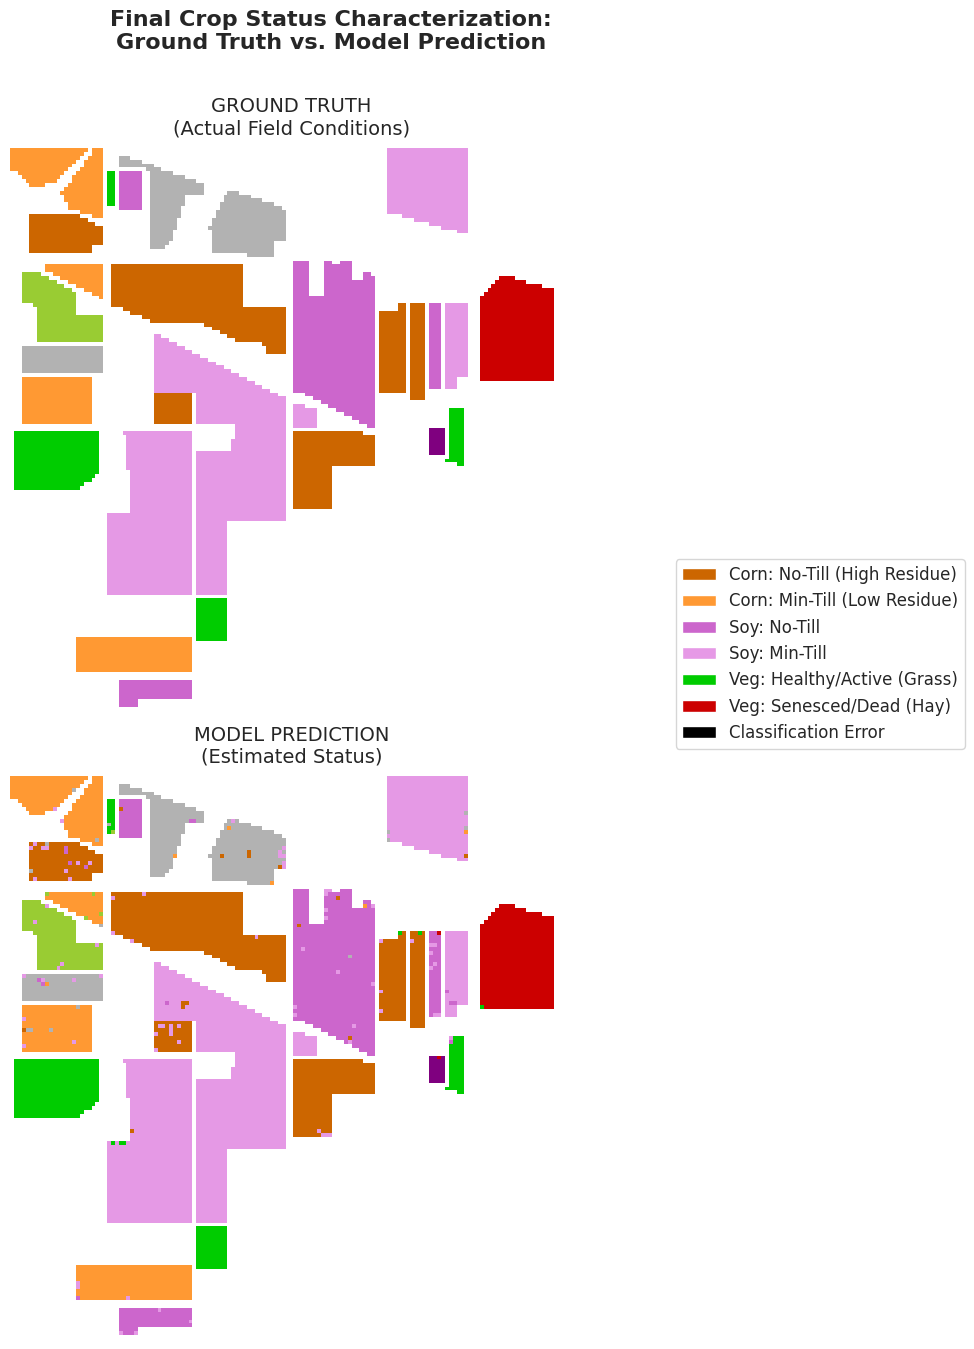

In [16]:
# ==========================================
# SECTION 11: INTEGRATED CROP STATUS MAP
# ==========================================
# Objective: Combine Physiological and Soil Health into a single
# plot using a vertical layout suitable for column-based reports.

print("Generating Full Scope Status Map...")

# 1. Define Color Palette for ALL 9 Classes
status_palette = {
    # Corn Group (Oranges)
    2: [0.8, 0.4, 0, 1],    # Corn-Notill (Dark Orange)
    3: [1.0, 0.6, 0.2, 1],  # Corn-Mintill (Light Orange)
    4: [0.6, 0.8, 0.2, 1],  # Corn (Greenish)

    # Soybean Group (Pinks/Purples)
    10: [0.8, 0.4, 0.8, 1], # Soy-Notill
    11: [0.9, 0.6, 0.9, 1], # Soy-Mintill
    12: [0.7, 0.7, 0.7, 1], # Soy-Clean (Grey-ish)

    # Vegetation/Health Group (Greens/Reds)
    5: [0, 0.8, 0, 1],      # Grass (Healthy/Active)
    7: [0.5, 0, 0.5, 1],    # Grass-Mowed (Stressed)
    8: [0.8, 0, 0, 1]       # Hay (Senesced/Dead)
}

targets = [2, 3, 5, 8]

# 2. Generate RGBA Arrays
H, W = y_img.shape
map_gt = np.zeros((H, W, 4)) + [1, 1, 1, 1.0]
map_pred = np.zeros((H, W, 4)) + [1, 1, 1, 1.0]

for r in range(H):
    for c in range(W):
        gt_val = y_img[r, c]
        pred_val = y_pred_map[r, c]

        # Check target scope
        if gt_val in TARGET_CLASSES:
            # Ground Truth Map
            if gt_val in status_palette:
                map_gt[r, c] = status_palette[gt_val]

            # Prediction Map
            if pred_val in status_palette:
                map_pred[r, c] = status_palette[pred_val]
            else:
                # Error (Black)
                map_pred[r, c] = [0, 0, 0, 1]
        else:
            map_gt[r, c] = [1, 1, 1, 0]
            map_pred[r, c] = [1, 1, 1, 0]

# 3. Plotting (Vertical Layout)
fig, axes = plt.subplots(2, 1, figsize=(8, 14))

# Main Title
plt.suptitle("Final Crop Status Characterization:\nGround Truth vs. Model Prediction", fontsize=16, weight='bold', y=0.96)

# Plot 1: Actual (Top)
axes[0].imshow(map_gt)
axes[0].set_title("GROUND TRUTH\n(Actual Field Conditions)", fontsize=14, pad=10)
axes[0].axis('off')

# Plot 2: Predicted (Bottom)
axes[1].imshow(map_pred)
axes[1].set_title("MODEL PREDICTION\n(Estimated Status)", fontsize=14, pad=10)
axes[1].axis('off')

# 4. Legend (Side Positioned)
from matplotlib.patches import Patch
legend_elements = [
    # Corn
    Patch(facecolor=status_palette[2], label='Corn: No-Till (High Residue)'),
    Patch(facecolor=status_palette[3], label='Corn: Min-Till (Low Residue)'),

    # Soy
    Patch(facecolor=status_palette[10], label='Soy: No-Till'),
    Patch(facecolor=status_palette[11], label='Soy: Min-Till'),

    # Health Status
    Patch(facecolor=status_palette[5], label='Veg: Healthy/Active (Grass)'),
    Patch(facecolor=status_palette[8], label='Veg: Senesced/Dead (Hay)'),

    # Error
    Patch(facecolor=[0, 0, 0, 1], label='Classification Error')
]

# Place legend to the right of the plots
fig.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(0.92, 0.5), fontsize=12)

# Adjust layout to make room for side legend
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()